# Cubo do Luís

## Resultados até agr:
### Usando que E é proporcional a P emitida
### Ordem decrescente de emissividade: Branca,Preta, Cinzenta, Espelhada
### Mas a Branca e a preta podem trocar pq a incerteza cobre
#### εpreta=1 εbranca=1.0276558636753108 εcinzenta=0.3477331322280471 εmetal=0.10492461556862633
Foram descartados os pontos antes do 6o mas depois vê-se oq sai 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../..")
import base as b
import importlib
importlib.reload(b)

C:\Users\appin\AppData\Local\Temp\ipykernel_17148\2486055907.py:3: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import RealData, Model, ODR
c:\Users\appin\OneDrive\Documents\GitHub\labs-II\semana2\T2B - Radiação Térmica\../..\base\plot.py:178: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.axhline(stdy, c="orange", label="Intervalo {}$\sigma$".format(tol))


<module 'base' from 'c:\\Users\\appin\\OneDrive\\Documents\\GitHub\\labs-II\\semana2\\T2B - Radiação Térmica\\../..\\base\\__init__.py'>

In [2]:
def u_T(R, uR):
    R = np.asarray(R)
    uR = np.asarray(uR)
    
    uT = np.zeros_like(R, dtype=float)
    
    m1 = R < 11000
    m2 = (R >= 11000) & (R < 22000)
    m3 = R >= 22000
    
    deriv1 = (-1.6705e-17*R[m1]**4
              + 4.732e-13*R[m1]**3
              - 4.977e-9*R[m1]**2
              + 2.384e-5*R[m1]
              - 4.978e-2)
    
    deriv2 = (-3.4905e-20*R[m2]**4
              + 2.8424e-15*R[m2]**3
              - 9.093e-11*R[m2]**2
              + 1.4188e-6*R[m2]
              - 1.074e-2)
    
    deriv3 = (-4.9955e-24*R[m3]**4
              + 2.6728e-18*R[m3]**3
              - 5.277e-13*R[m3]**2
              + 4.712e-8*R[m3]
              - 1.818e-3)
    
    uT[m1] = np.abs(deriv1) * uR[m1]
    uT[m2] = np.abs(deriv2) * uR[m2]
    uT[m3] = np.abs(deriv3) * uR[m3]
    
    return uT

In [3]:
wE,wuE,wR,wuR,wT=np.genfromtxt('whiteERval.txt',unpack=True)
wT4=wT**4
wuT4=4*wT**3*u_T(wR,wuR)

In [4]:
bE,buE,bR,buR,bT=np.genfromtxt('blackERval.txt',unpack=True)
bT4=bT**4
buT4=4*bT**3*u_T(bR,buR)

In [5]:
gE,guE,gR,guR,gT=np.genfromtxt('greyERval.txt',unpack=True)
gT4=gT**4
guT4=4*gT**3*u_T(gR,guR)

In [6]:
mE,muE,mR,muR,mT=np.genfromtxt('metalERval.txt',unpack=True)
mT4=mT**4
muT4=4*mT**3*u_T(mR,muR)

In [7]:
wajuste = b.fullLinAnalysis(wT4,wE,wuT4,wuE,"Face branca","T(k^4)","E(mV)",3)
wajuste.pprint()
bajuste =b.fullLinAnalysis(bT4[6:],bE[6:],buT4[6:],buE[6:],"Face preta","T(k^4)","E(mV)",3)
bajuste.pprint()
gajuste =b.fullLinAnalysis(gT4[6:],gE[6:],guT4[6:],guE[6:],"Face cinzenta","T(k^4)","E(mV)",3)
gajuste.pprint()
majuste =b.fullLinAnalysis(mT4[6:],mE[6:],muT4[6:],muE[6:],"Face espelhada","T(k^4)","E(mV)",3)
majuste.pprint()

c:\Users\appin\OneDrive\Documents\GitHub\labs-II\semana2\T2B - Radiação Térmica\../..\base\plot.py:178: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.axhline(stdy, c="orange", label="Intervalo {}$\sigma$".format(tol))


TypeError: object of type 'numpy.int64' has no len()

Beta: [4.78597217e-08 4.32097068e+00]
Beta Std Error: [3.57461801e-09 3.40303028e-01]
Beta Covariance: [[ 3.16390151e-19 -2.53742031e-11]
 [-2.53742031e-11  2.86744637e-03]]
Residual Variance: 40.38650968141142
Inverse Condition #: 5.6597521880030905e-09
Reason(s) for Halting:
  Sum of squares convergence


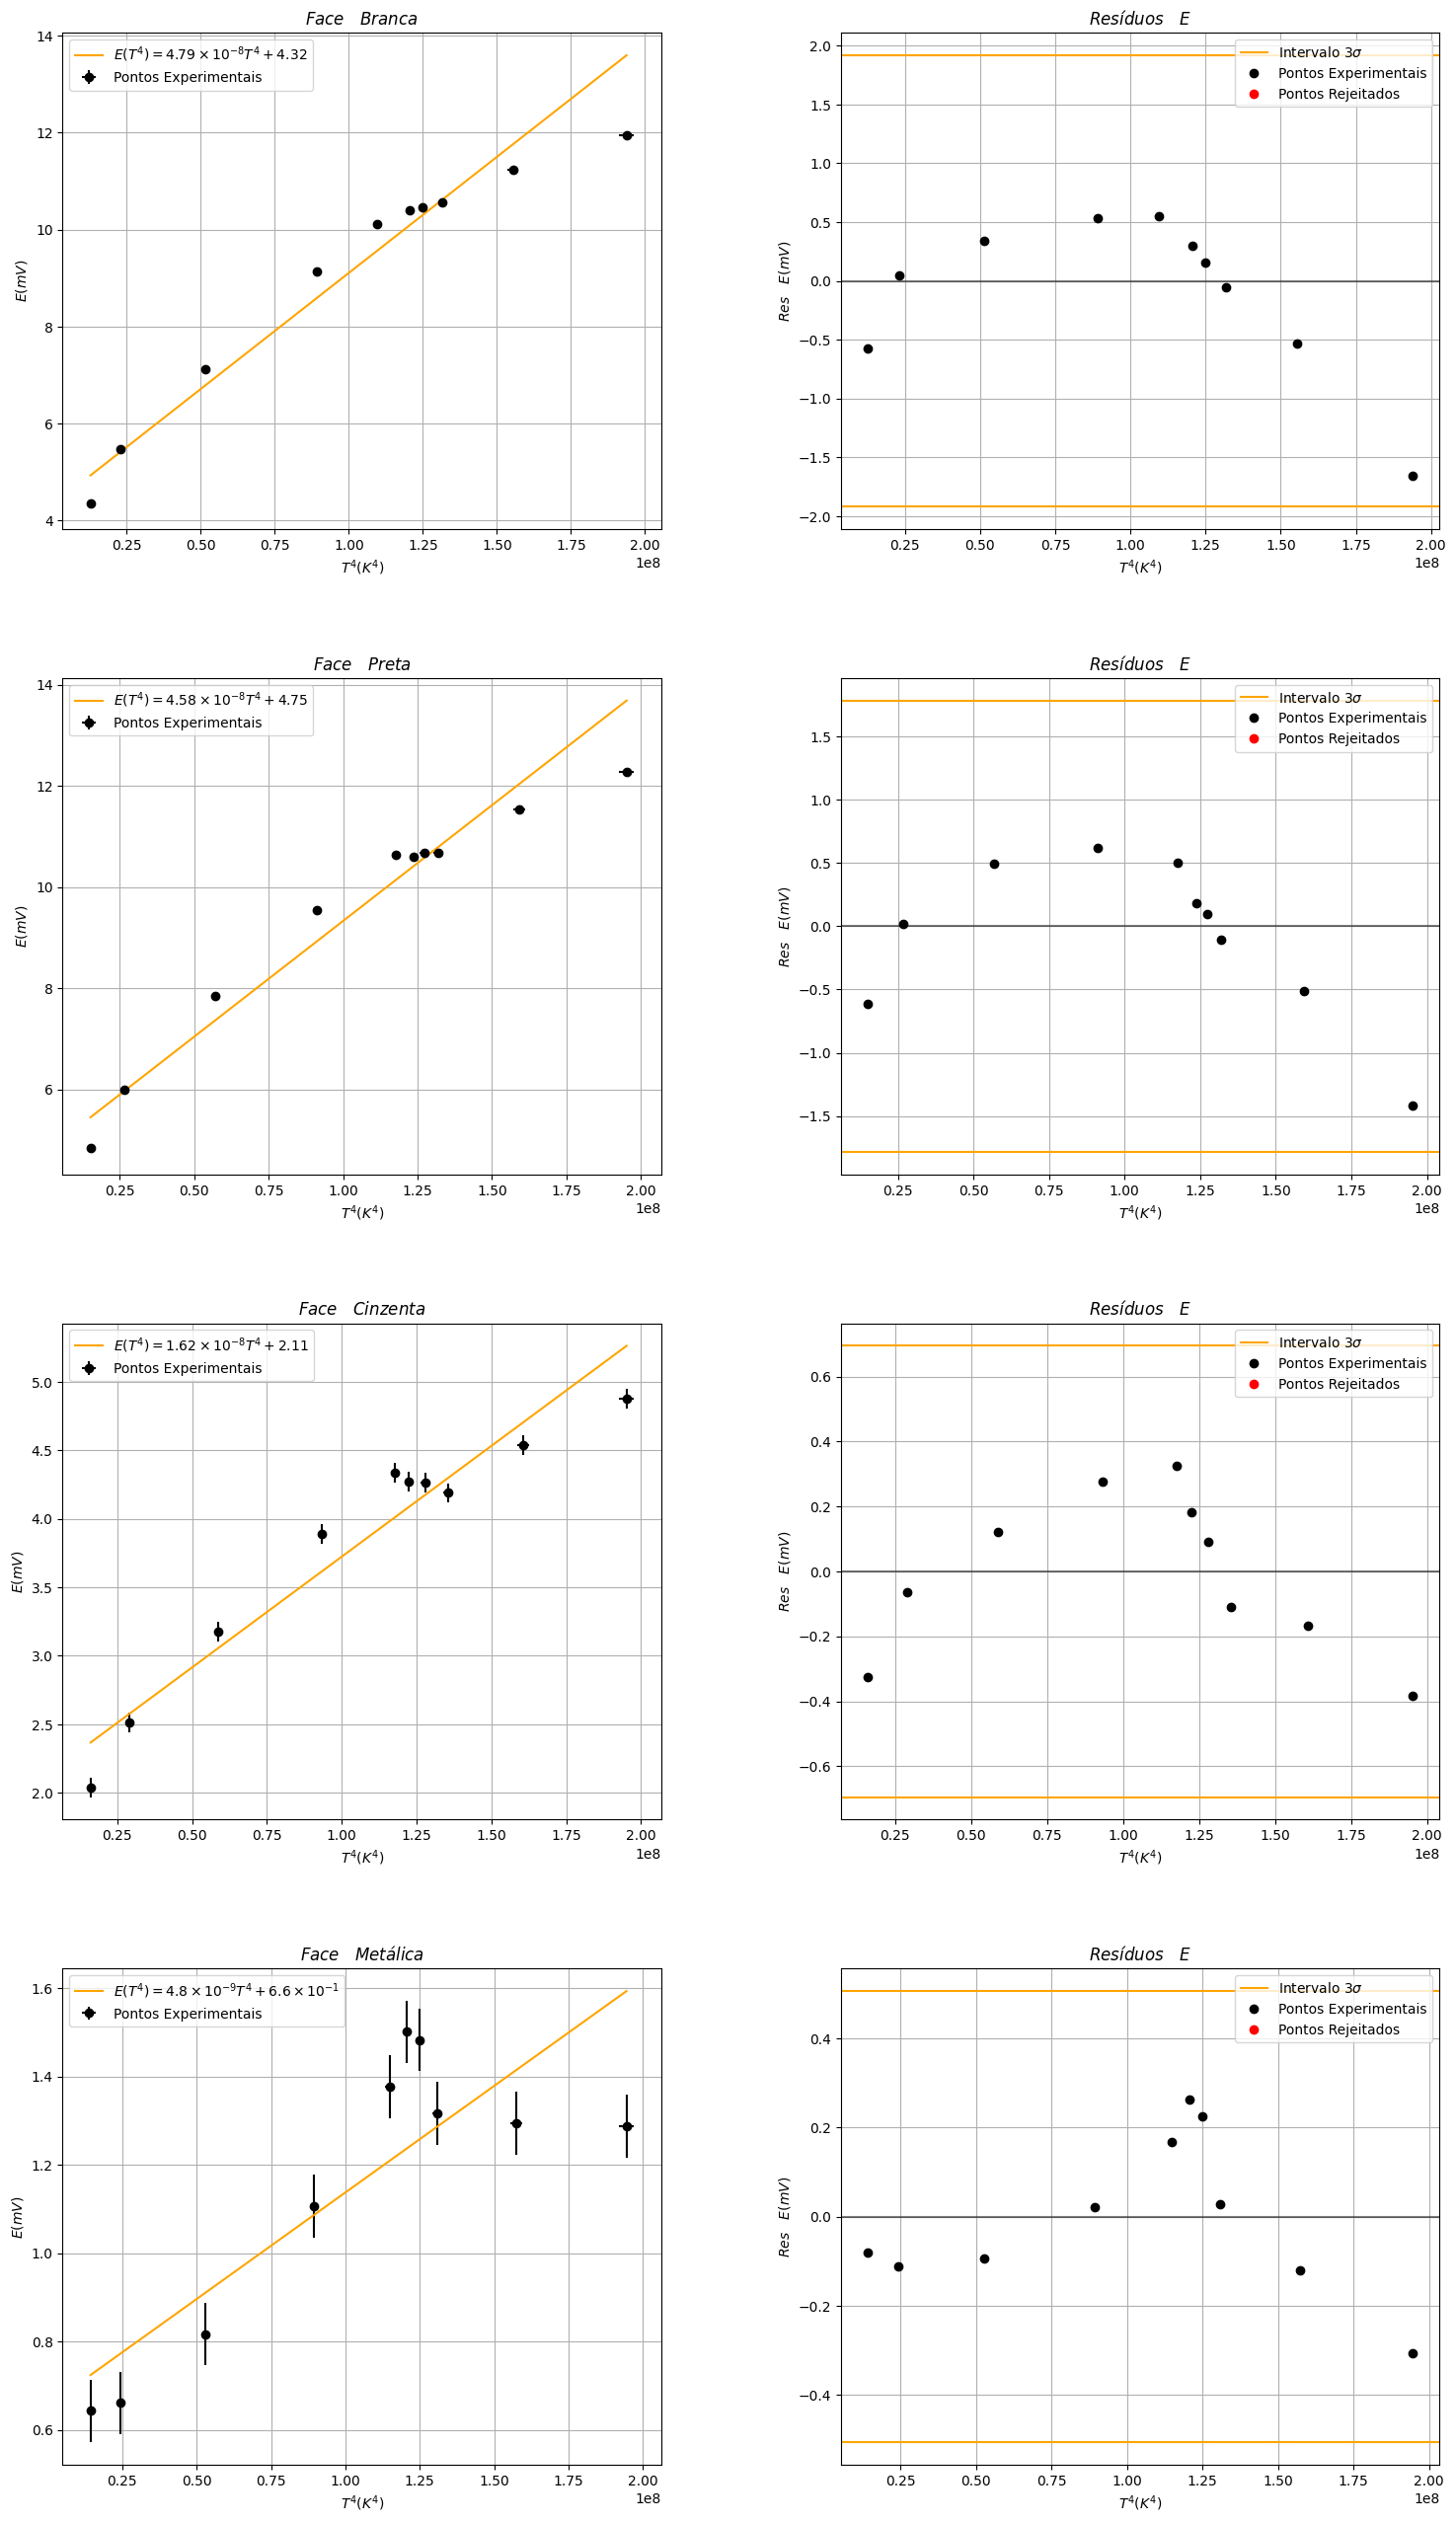

In [9]:
xs = [wT4[6:],bT4[6:],gT4[6:],mT4[6:]]
ys = [wE[6:],bE[6:],gE[6:],mE[6:]]
xerrs = [wuT4[6:],buT4[6:],guT4[6:],muT4[6:]]
yerrs = [wuE[6:],buE[6:],guE[6:],muE[6:]]
titles = ["Face \\quad Branca", "Face \\quad Preta", "Face \\quad Cinzenta", "Face \\quad Metálica"]

adjusts = b.plotColumnFullLinReg(xs,ys,xerrs,yerrs,titles,"T^4(K^4)","E(mV)",tol=3)
wajuste = adjusts[0]
bajuste = adjusts[1]
gajuste = adjusts[2]
majuste = adjusts[3]
wajuste.pprint()

εpreta=1 εbranca=1.159427456076725 εcinzenta=0.3571620526622077 εmetal=0.12684029732301286


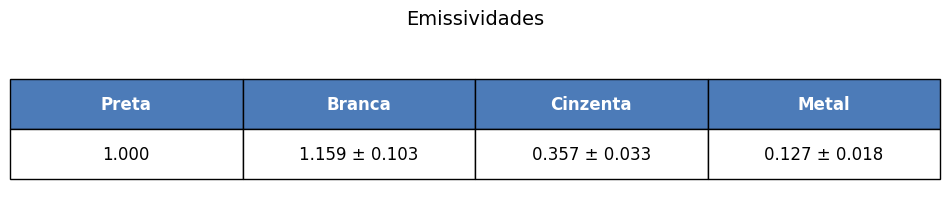

In [ ]:
#Normalização relativamente à face preta
εpreta=1
εb=bajuste.beta[0]/wajuste.beta[0]
εc=bajuste.beta[0]/gajuste.beta[0]
εm=bajuste.beta[0]/majuste.beta[0]
print('εpreta=1','εbranca={}'.format(1/εb),'εcinzenta={}'.format(1/εc),'εmetal={}'.format(1/εm))

ub = np.sqrt((wajuste.sd_beta[0]/bajuste.beta[0])**2+(wajuste.beta[0]/bajuste.beta[0]**2*wajuste.sd_beta[0])**2)
uc = np.sqrt((gajuste.sd_beta[0]/bajuste.beta[0])**2+(gajuste.beta[0]/bajuste.beta[0]**2*gajuste.sd_beta[0])**2)
um = np.sqrt((majuste.sd_beta[0]/bajuste.beta[0])**2+(majuste.beta[0]/bajuste.beta[0]**2*majuste.sd_beta[0])**2)

columns = ["Preta","Branca","Cinzenta","Metal"]
data =[[f"{εpreta:.3f}",f"{1/εb:.3f} ± {ub:.3f}",f"{1/εc:.3f} ± {uc:.3f}",f"{1/εm:.3f} ± {um:.3f}"]]
b.getTable(columns,data,"Emissividades",None)